# 02 — Análise Exploratória dos Dados (EDA) do NPS

## Objetivo do notebook

Este notebook tem como objetivo realizar uma **Análise Exploratória dos Dados (EDA)** com foco em negócio para o projeto **NPS Preditivo**.

A análise busca compreender quais fatores operacionais, logísticos, comerciais e de atendimento estão mais associados à satisfação dos clientes em um cenário de e-commerce.

## Perguntas orientadoras da EDA

Este notebook responde às perguntas propostas na Etapa 3 do desafio:

1. Quais fatores parecem mais críticos para a satisfação?
2. O que mais gera detratores?
3. Existe algum ponto de ruptura na experiência do cliente?
4. Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

## Abordagem

1. Validação da estrutura e qualidade da base.
2. Criação de variáveis analíticas para leitura de negócio.
3. Análise do NPS por logística, atendimento, reclamações, perfil e recompra.
4. Consolidação dos principais insights e recomendações práticas.

In [48]:
# CÉLULA 1 — IMPORTAÇÃO DAS BIBLIOTECAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid")

In [49]:
# CÉLULA 2 — DEFINIÇÃO DOS CAMINHOS DO PROJETO

BASE_DIR = Path("..")

RAW_DATA_PATH = BASE_DIR / "data" / "raw" / "desafio_nps_fase_1.csv"
PROCESSED_DATA_PATH = BASE_DIR / "data" / "processed" / "base_nps_tratada.csv"
FIGURES_PATH = BASE_DIR / "reports" / "figures"

FIGURES_PATH.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

print("Caminho da base bruta:", RAW_DATA_PATH)
print("Caminho da base tratada:", PROCESSED_DATA_PATH)
print("Caminho das figuras:", FIGURES_PATH)

Caminho da base bruta: ..\data\raw\desafio_nps_fase_1.csv
Caminho da base tratada: ..\data\processed\base_nps_tratada.csv
Caminho das figuras: ..\reports\figures


In [50]:
# CÉLULA 3 — LEITURA DA BASE DE DADOS

df = pd.read_csv(RAW_DATA_PATH)

df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.90,0,3,6.50
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.40,0,3,0.00
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.80,0,7,1.50
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.90,0,4,0.30
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.10,0,3,7.90


In [51]:
# CÉLULA 4 — VISÃO GERAL DA BASE

print("Quantidade de linhas:", df.shape[0])
print("Quantidade de colunas:", df.shape[1])

df.info()

Quantidade de linhas: 2500
Quantidade de colunas: 19
<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   str    
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  custom

## 1. Validação inicial da base

Antes de analisar padrões de satisfação, é necessário validar se a base está adequada para análise.

Nesta etapa, verificamos:

- quantidade de registros;
- quantidade de colunas;
- tipos de dados;
- valores ausentes;
- registros duplicados;
- consistência da variável `nps_score`.

Essa verificação reduz o risco de interpretar problemas de qualidade de dados como se fossem padrões reais de negócio.


## Dicionário de Dados

A base de dados utilizada neste projeto contém informações históricas de pedidos, entregas, interações com atendimento e indicadores de satisfação do cliente.

| Variável | Descrição |
|---|---|
| `customer_id` | Identificador único do cliente. |
| `order_id` | Identificador único do pedido. |
| `customer_age` | Idade do cliente. |
| `customer_region` | Região geográfica do cliente. |
| `customer_tenure_months` | Tempo de relacionamento do cliente com a empresa, em meses. |
| `order_value` | Valor total do pedido. |
| `items_quantity` | Quantidade de itens no pedido. |
| `discount_value` | Valor de desconto aplicado ao pedido. |
| `payment_installments` | Número de parcelas do pagamento. |
| `delivery_time_days` | Tempo total de entrega, em dias. |
| `delivery_delay_days` | Quantidade de dias de atraso na entrega. |
| `freight_value` | Valor do frete. |
| `delivery_attempts` | Número de tentativas de entrega. |
| `customer_service_contacts` | Número de contatos do cliente com o atendimento. |
| `resolution_time_days` | Tempo para resolução de problemas, em dias. |
| `complaints_count` | Número de reclamações registradas pelo cliente. |
| `repeat_purchase_30d` | Indica se houve recompra em até 30 dias após o pedido: `0 = não`, `1 = sim`. |
| `csat_internal_score` | Score interno de satisfação do cliente. |
| `nps_score` | Nota de satisfação do cliente, variando de 0 a 10, coletada após a experiência de compra. |

In [52]:
# CÉLULA 5 — VALIDAÇÃO DE VALORES NULOS

valores_nulos = (
    df.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "coluna", 0: "qtd_nulos"})
)

valores_nulos["perc_nulos"] = valores_nulos["qtd_nulos"] / len(df) * 100

valores_nulos.sort_values("qtd_nulos", ascending=False)

,coluna,qtd_nulos,perc_nulos
0,customer_id,0,0.00
1,customer_age,0,0.00
2,customer_region,0,0.00
3,customer_tenure_months,0,0.00
4,order_id,0,0.00
5,order_value,0,0.00
6,items_quantity,0,0.00
7,discount_value,0,0.00
8,payment_installments,0,0.00
9,delivery_time_days,0,0.00


In [53]:
# CÉLULA 6 — VALIDAÇÃO DE DUPLICIDADES

qtd_duplicados = df.duplicated().sum()

print("Quantidade de registros duplicados:", qtd_duplicados)

Quantidade de registros duplicados: 0


In [54]:
# CÉLULA 7 — VALIDAÇÃO DA VARIÁVEL NPS

print("Menor valor de NPS:", df["nps_score"].min())
print("Maior valor de NPS:", df["nps_score"].max())
print("Média do NPS:", round(df["nps_score"].mean(), 2))
print("Mediana do NPS:", round(df["nps_score"].median(), 2))

Menor valor de NPS: 0.0
Maior valor de NPS: 10.0
Média do NPS: 4.38
Mediana do NPS: 4.4


## 2. Criação de variáveis analíticas

A nota de NPS varia de 0 a 10. Para interpretar o comportamento dos clientes de forma aderente ao negócio, criaremos uma classificação em três grupos:

| Faixa de nota | Classificação | Interpretação |
|---:|---|---|
| 0 a 6 | Detrator | Cliente insatisfeito, com maior risco de reclamação ou abandono |
| 7 a 8 | Neutro | Cliente satisfeito parcialmente, mas sem forte vínculo com a marca |
| 9 a 10 | Promotor | Cliente altamente satisfeito, com maior chance de recomendar e recomprar |

Além disso, serão criadas faixas para variáveis operacionais como atraso, reclamações, contatos com atendimento e tempo de resolução. Isso facilita a identificação de possíveis pontos de ruptura na experiência.

In [55]:
# CÉLULA 8 — CRIAÇÃO DAS VARIÁVEIS ANALÍTICAS

df_eda = df.copy()

df_eda["nps_class"] = pd.cut(
    df_eda["nps_score"],
    bins=[-0.01, 6, 8, 10],
    labels=["Detrator", "Neutro", "Promotor"]
)

df_eda["nps_binary"] = np.where(
    df_eda["nps_score"] >= 7,
    "Satisfeito",
    "Insatisfeito"
)

df_eda["has_delay"] = np.where(df_eda["delivery_delay_days"] > 0, "Com atraso", "Sem atraso")
df_eda["has_complaint"] = np.where(df_eda["complaints_count"] > 0, "Com reclamação", "Sem reclamação")
df_eda["has_service_contact"] = np.where(df_eda["customer_service_contacts"] > 0, "Com contato", "Sem contato")

df_eda["delay_band"] = pd.cut(
    df_eda["delivery_delay_days"],
    bins=[-0.01, 0, 1, 2, 3, 5, np.inf],
    labels=["0", "1", "2", "3", "4-5", "6+"]
)

df_eda["contacts_band"] = pd.cut(
    df_eda["customer_service_contacts"],
    bins=[-0.01, 0, 1, 2, 3, np.inf],
    labels=["0", "1", "2", "3", "4+"]
)

df_eda["complaints_band"] = pd.cut(
    df_eda["complaints_count"],
    bins=[-0.01, 0, 1, 2, 3, 5, np.inf],
    labels=["0", "1", "2", "3", "4-5", "6+"]
)

df_eda["resolution_band"] = pd.cut(
    df_eda["resolution_time_days"],
    bins=[-0.01, 2, 5, 8, np.inf],
    labels=["0-2", "3-5", "6-8", "9+"]
)

df_eda["age_band"] = pd.cut(
    df_eda["customer_age"],
    bins=[0, 25, 35, 45, 55, 65, np.inf],
    labels=["Até 25", "26-35", "36-45", "46-55", "56-65", "66+"]
)

df_eda["tenure_band"] = pd.cut(
    df_eda["customer_tenure_months"],
    bins=[-0.01, 12, 36, 60, 84, np.inf],
    labels=["0-12", "13-36", "37-60", "61-84", "85+"]
)

df_eda.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,nps_class,nps_binary,has_delay,has_complaint,has_service_contact,delay_band,contacts_band,complaints_band,resolution_band,age_band,tenure_band
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.90,0,3,6.50,Neutro,Insatisfeito,Com atraso,Com reclamação,Sem contato,2,0,3,3-5,56-65,13-36
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.40,0,3,0.00,Detrator,Insatisfeito,Com atraso,Com reclamação,Sem contato,4-5,0,3,9+,Até 25,0-12
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.80,0,7,1.50,Detrator,Insatisfeito,Com atraso,Com reclamação,Com contato,1,4+,6+,3-5,46-55,85+
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.90,0,4,0.30,Detrator,Insatisfeito,Com atraso,Com reclamação,Com contato,2,1,4-5,9+,46-55,85+
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.10,0,3,7.90,Neutro,Insatisfeito,Com atraso,Com reclamação,Com contato,1,1,3,0-2,56-65,37-60


## 3. Distribuição geral do NPS

A primeira pergunta da análise é: **qual é o nível geral de satisfação da base?**

Para isso, observamos:

- distribuição da nota `nps_score`;
- proporção de detratores, neutros e promotores;
- NPS médio por grupo;
- taxa de recompra em até 30 dias por classificação de NPS.

In [56]:
# CÉLULA 9 — ESTATÍSTICAS GERAIS DO NPS

resumo_nps = pd.DataFrame({
    "indicador": [
        "qtd_clientes",
        "nps_medio",
        "nps_mediano",
        "nps_minimo",
        "nps_maximo",
        "taxa_recompra_30d"
    ],
    "valor": [
        len(df_eda),
        df_eda["nps_score"].mean(),
        df_eda["nps_score"].median(),
        df_eda["nps_score"].min(),
        df_eda["nps_score"].max(),
        df_eda["repeat_purchase_30d"].mean()
    ]
})

resumo_nps

,indicador,valor
0,qtd_clientes,2500.00
1,nps_medio,4.38
2,nps_mediano,4.40
3,nps_minimo,0.00
4,nps_maximo,10.00
5,taxa_recompra_30d,0.09


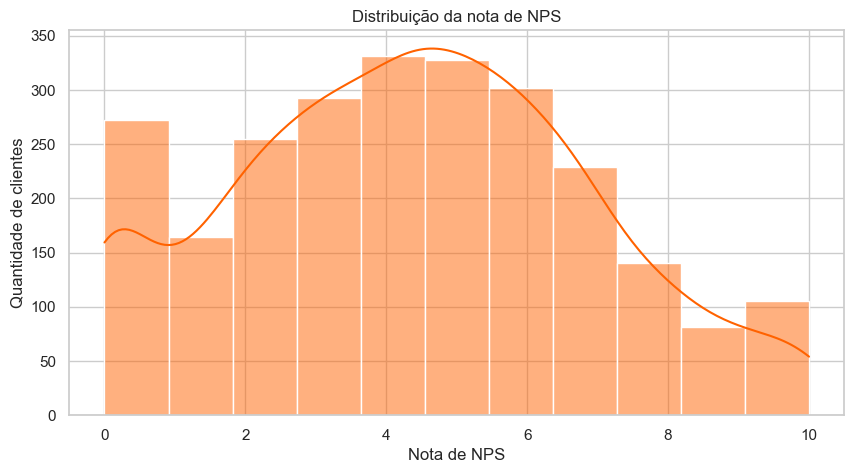

In [114]:
# CÉLULA 10 — DISTRIBUIÇÃO DA NOTA DE NPS

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_eda,
    x="nps_score",
    bins=11,
    kde=True,
    color='#ff6200'
)

plt.title("Distribuição da nota de NPS")
plt.xlabel("Nota de NPS")
plt.ylabel("Quantidade de clientes")

plt.savefig(FIGURES_PATH / "distribuicao_nps.png", dpi=300, bbox_inches="tight")
plt.show()

In [58]:
# CÉLULA 11 — DISTRIBUIÇÃO POR CLASSE DE NPS

dist_nps = (
    df_eda["nps_class"]
    .value_counts()
    .rename_axis("nps_class")
    .reset_index(name="qtd_clientes")
)

dist_nps["perc_clientes"] = dist_nps["qtd_clientes"] / len(df_eda) * 100

dist_nps

,nps_class,qtd_clientes,perc_clientes
0,Detrator,1851,74.04
1,Neutro,448,17.92
2,Promotor,201,8.04


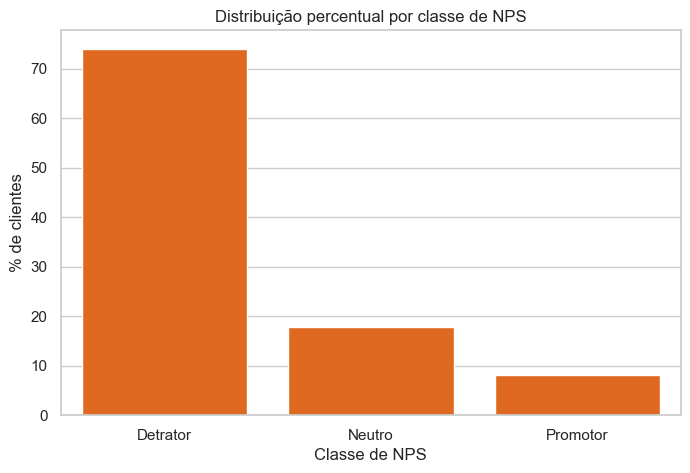

In [94]:
# CÉLULA 12 — GRÁFICO DA DISTRIBUIÇÃO POR CLASSE DE NPS

plt.figure(figsize=(8, 5))

ordem_nps = ["Detrator", "Neutro", "Promotor"]

sns.barplot(
    data=dist_nps,
    x="nps_class",
    y="perc_clientes",
    order=ordem_nps,
    color='#ff6200'
)

plt.title("Distribuição percentual por classe de NPS")
plt.xlabel("Classe de NPS")
plt.ylabel("% de clientes")

plt.savefig(FIGURES_PATH / "distribuicao_classes_nps.png", dpi=300, bbox_inches="tight")
plt.show()

In [60]:
# CÉLULA 13 — RECOMPRA POR CLASSE DE NPS

recompra_por_nps = (
    df_eda
    .groupby("nps_class", observed=False)
    .agg(
        qtd_clientes=("customer_id", "count"),
        nps_medio=("nps_score", "mean"),
        taxa_recompra_30d=("repeat_purchase_30d", "mean")
    )
    .reset_index()
)

recompra_por_nps["taxa_recompra_30d"] = recompra_por_nps["taxa_recompra_30d"] * 100

recompra_por_nps

,nps_class,qtd_clientes,nps_medio,taxa_recompra_30d
0,Detrator,1851,3.26,0.00
1,Neutro,448,6.89,3.79
2,Promotor,201,9.10,100.00


### Interpretação

A distribuição geral do NPS permite avaliar se a base está concentrada em clientes satisfeitos ou insatisfeitos.

A análise por classe é importante porque, para o negócio, um cliente detrator não representa apenas uma nota baixa. Ele pode indicar risco de reclamação, perda de recompra, impacto negativo no boca a boca e necessidade de priorização operacional.

A taxa de recompra por classe ajuda a conectar satisfação com comportamento posterior do cliente.

## 4. Quais fatores parecem mais críticos para a satisfação?

Para identificar fatores críticos, analisaremos a associação entre o `nps_score` e as principais variáveis operacionais da base.

A correlação será usada como primeira leitura exploratória. Ela não prova causalidade, mas ajuda a priorizar variáveis que merecem investigação mais profunda.

In [61]:
# CÉLULA 14 — CORRELAÇÃO DAS VARIÁVEIS NUMÉRICAS COM O NPS

colunas_excluir = ["customer_id", "order_id"]

numeric_cols = [
    col for col in df_eda.select_dtypes(include=["number"]).columns
    if col not in colunas_excluir
]

correlacao_nps = (
    df_eda[numeric_cols]
    .corr(numeric_only=True)["nps_score"]
    .sort_values()
    .reset_index()
    .rename(columns={"index": "variavel", "nps_score": "correlacao_com_nps"})
)

correlacao_nps

,variavel,correlacao_com_nps
0,delivery_delay_days,-0.60
1,complaints_count,-0.50
2,customer_service_contacts,-0.35
3,resolution_time_days,-0.19
4,freight_value,-0.04
5,customer_age,-0.01
6,customer_tenure_months,-0.01
7,delivery_time_days,0.00
8,items_quantity,0.01
9,payment_installments,0.02


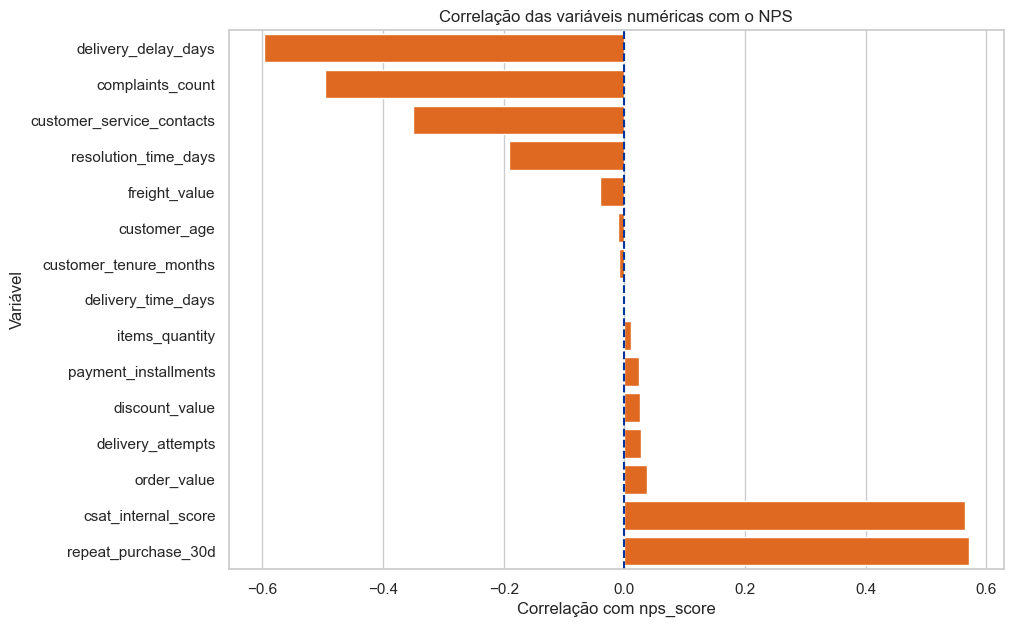

In [97]:
# CÉLULA 15 — GRÁFICO DE CORRELAÇÃO COM O NPS

plt.figure(figsize=(10, 7))

sns.barplot(
    data=correlacao_nps[correlacao_nps["variavel"] != "nps_score"],
    y="variavel",
    x="correlacao_com_nps",
    color='#ff6200'
)

plt.axvline(0, linestyle="--", color='#003399')

plt.title("Correlação das variáveis numéricas com o NPS")
plt.xlabel("Correlação com nps_score")
plt.ylabel("Variável")

plt.savefig(FIGURES_PATH / "correlacao_variaveis_nps.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretação

Variáveis com correlação negativa indicam fatores associados à redução do NPS.  
Variáveis com correlação positiva indicam fatores associados ao aumento do NPS.

Na leitura de negócio, os fatores mais críticos devem ser avaliados principalmente em três grupos:

1. **Logística**: atraso, tempo de entrega e tentativas de entrega.
2. **Atendimento**: contatos, reclamações e tempo de resolução.
3. **Relacionamento e comportamento**: recompra e score interno de satisfação.

A correlação não deve ser interpretada como causa direta, mas como sinal de priorização para aprofundamento.

In [63]:
# CÉLULA 16 — FUNÇÃO AUXILIAR PARA RESUMOS DE NEGÓCIO

def resumo_por_grupo(df, coluna_grupo):
    # Gera um resumo executivo por grupo.
    resumo = (
        df
        .groupby(coluna_grupo, observed=False)
        .agg(
            qtd_clientes=("customer_id", "count"),
            nps_medio=("nps_score", "mean"),
            perc_detratores=("nps_class", lambda x: (x == "Detrator").mean() * 100),
            perc_promotores=("nps_class", lambda x: (x == "Promotor").mean() * 100),
            taxa_recompra_30d=("repeat_purchase_30d", lambda x: x.mean() * 100)
        )
        .reset_index()
    )

    return resumo.round(2)

## 5. Impacto do atraso na satisfação

Atraso na entrega é um fator operacional com forte potencial de afetar a experiência do cliente em e-commerce. Nesta seção, analisaremos o NPS médio e a proporção de detratores conforme a quantidade de dias de atraso aumenta.

A análise por faixa facilita a leitura executiva, pois mostra como a satisfação muda conforme o problema operacional se intensifica.

In [64]:
# CÉLULA 17 — RESUMO POR DIAS DE ATRASO

resumo_atraso = resumo_por_grupo(df_eda, "delay_band")

resumo_atraso

,delay_band,qtd_clientes,nps_medio,perc_detratores,perc_promotores,taxa_recompra_30d
0,0,277,6.86,36.46,31.05,33.94
1,1,615,5.55,59.67,13.98,14.80
2,2,646,4.58,75.39,3.41,4.02
3,3,525,3.44,89.71,1.14,1.14
4,4-5,386,2.15,96.89,0.26,0.26
5,6+,51,0.81,100.00,0.00,0.00


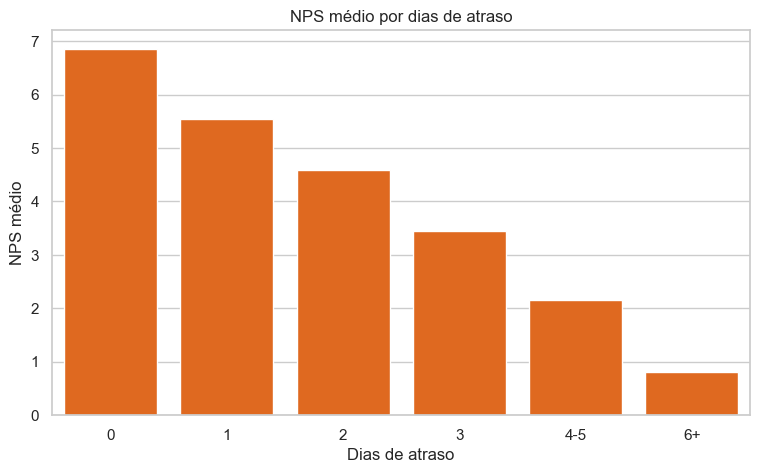

In [98]:
# CÉLULA 18 — NPS MÉDIO POR DIAS DE ATRASO

plt.figure(figsize=(9, 5))

sns.barplot(
    data=resumo_atraso,
    x="delay_band",
    y="nps_medio",
    color='#ff6200'
)

plt.title("NPS médio por dias de atraso")
plt.xlabel("Dias de atraso")
plt.ylabel("NPS médio")

plt.savefig(FIGURES_PATH / "nps_por_atraso.png", dpi=300, bbox_inches="tight")
plt.show()

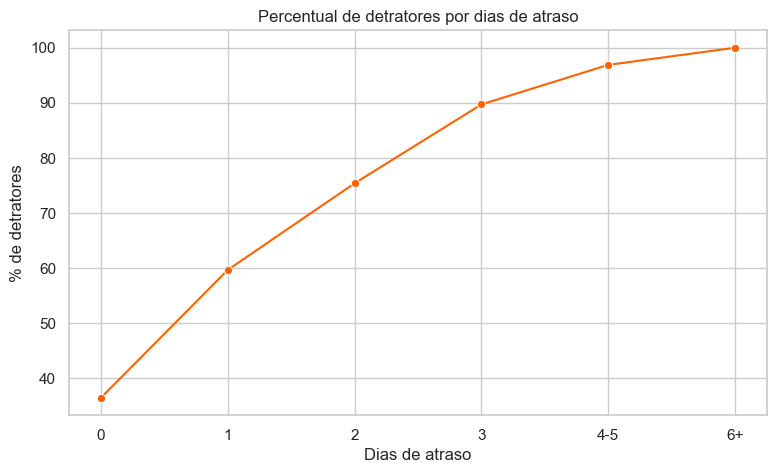

In [100]:
# CÉLULA 19 — DETRATORES POR DIAS DE ATRASO

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=resumo_atraso,
    x="delay_band",
    y="perc_detratores",
    marker="o",
    color='#ff6200'
)

plt.title("Percentual de detratores por dias de atraso")
plt.xlabel("Dias de atraso")
plt.ylabel("% de detratores")

plt.savefig(FIGURES_PATH / "detratores_por_atraso.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretação

Para um gestor de operações, a principal pergunta não é apenas se essa variável afeta o NPS, mas **a partir de qual faixa a experiência começa a se deteriorar de forma relevante**.

Quando o percentual de detratores aumenta conforme a faixa operacional piora, a variável pode ser usada como gatilho para ações preventivas, priorização de atendimento ou revisão de processo.

## 6. Impacto das reclamações na satisfação

Reclamações registradas são sinais diretos de fricção na jornada do cliente. Nesta seção, analisamos como a quantidade de reclamações se relaciona com o NPS médio, percentual de detratores e recompra.

A análise por faixa facilita a leitura executiva, pois mostra como a satisfação muda conforme o problema operacional se intensifica.

In [67]:
# CÉLULA 20 — RESUMO POR QUANTIDADE DE RECLAMAÇÕES

resumo_reclamacoes = resumo_por_grupo(df_eda, "complaints_band")

resumo_reclamacoes

,complaints_band,qtd_clientes,nps_medio,perc_detratores,perc_promotores,taxa_recompra_30d
0,0,23,8.52,4.35,60.87,69.57
1,1,122,7.77,8.20,41.80,42.62
2,2,277,6.05,43.32,18.05,19.49
3,3,507,4.91,67.65,8.09,8.88
4,4-5,1044,3.98,84.20,3.83,4.31
5,6+,527,2.82,94.50,0.95,1.14


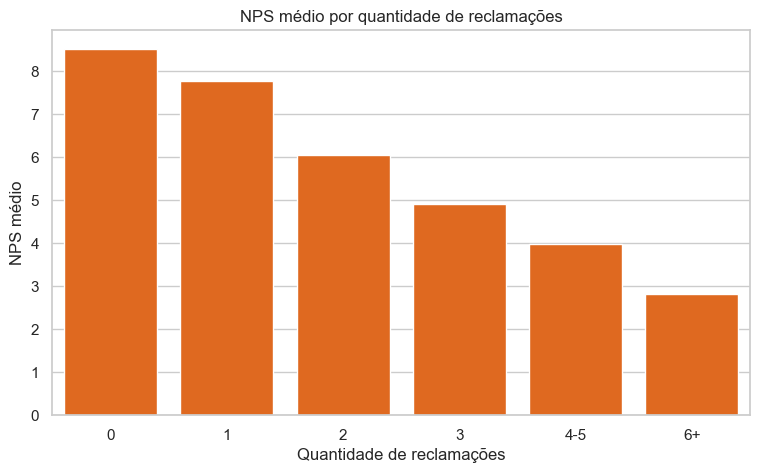

In [101]:
# CÉLULA 21 — NPS MÉDIO POR QUANTIDADE DE RECLAMAÇÕES

plt.figure(figsize=(9, 5))

sns.barplot(
    data=resumo_reclamacoes,
    x="complaints_band",
    y="nps_medio",
    color='#ff6200'
)

plt.title("NPS médio por quantidade de reclamações")
plt.xlabel("Quantidade de reclamações")
plt.ylabel("NPS médio")

plt.savefig(FIGURES_PATH / "nps_por_reclamacoes.png", dpi=300, bbox_inches="tight")
plt.show()

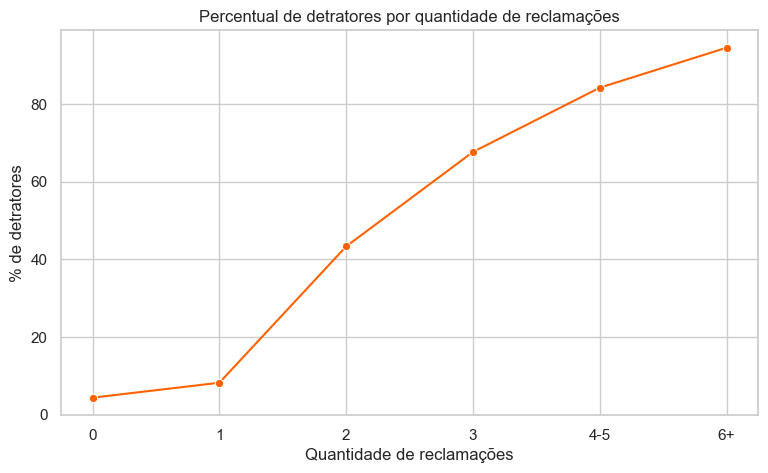

In [102]:
# CÉLULA 22 — DETRATORES POR QUANTIDADE DE RECLAMAÇÕES

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=resumo_reclamacoes,
    x="complaints_band",
    y="perc_detratores",
    marker="o",
    color='#ff6200'
)

plt.title("Percentual de detratores por quantidade de reclamações")
plt.xlabel("Quantidade de reclamações")
plt.ylabel("% de detratores")

plt.savefig(FIGURES_PATH / "detratores_por_reclamacoes.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretação

Para um gestor de operações, a principal pergunta não é apenas se essa variável afeta o NPS, mas **a partir de qual faixa a experiência começa a se deteriorar de forma relevante**.

Quando o percentual de detratores aumenta conforme a faixa operacional piora, a variável pode ser usada como gatilho para ações preventivas, priorização de atendimento ou revisão de processo.

## 7. Impacto dos contatos com atendimento

Contatos com atendimento indicam o esforço necessário para o cliente resolver um problema. Em geral, quanto maior o esforço do cliente, maior tende a ser a insatisfação.

A análise por faixa facilita a leitura executiva, pois mostra como a satisfação muda conforme o problema operacional se intensifica.

In [70]:
# CÉLULA 23 — RESUMO POR QUANTIDADE DE CONTATOS

resumo_contatos = resumo_por_grupo(df_eda, "contacts_band")

resumo_contatos

,contacts_band,qtd_clientes,nps_medio,perc_detratores,perc_promotores,taxa_recompra_30d
0,0,554,5.54,59.21,16.97,17.87
1,1,816,4.66,70.34,8.21,9.19
2,2,640,4.12,79.06,4.84,5.31
3,3,314,3.20,88.54,2.55,2.87
4,4+,176,2.47,93.75,0.57,0.57


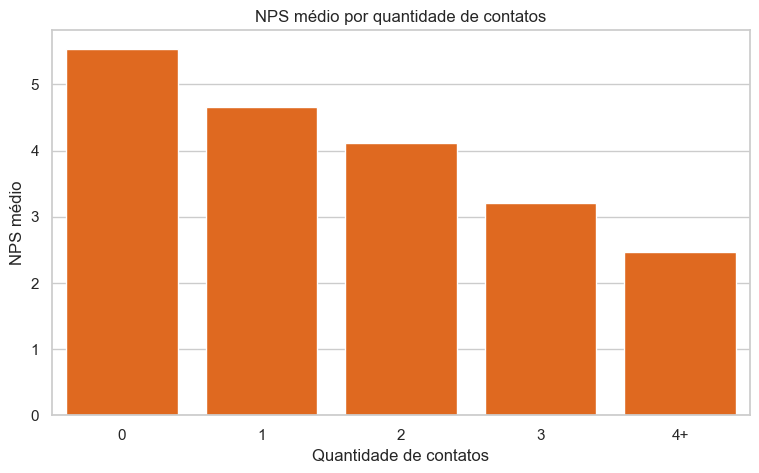

In [103]:
# CÉLULA 24 — NPS MÉDIO POR QUANTIDADE DE CONTATOS

plt.figure(figsize=(9, 5))

sns.barplot(
    data=resumo_contatos,
    x="contacts_band",
    y="nps_medio",
    color='#ff6200'
)

plt.title("NPS médio por quantidade de contatos")
plt.xlabel("Quantidade de contatos")
plt.ylabel("NPS médio")

plt.savefig(FIGURES_PATH / "nps_por_contatos_atendimento.png", dpi=300, bbox_inches="tight")
plt.show()

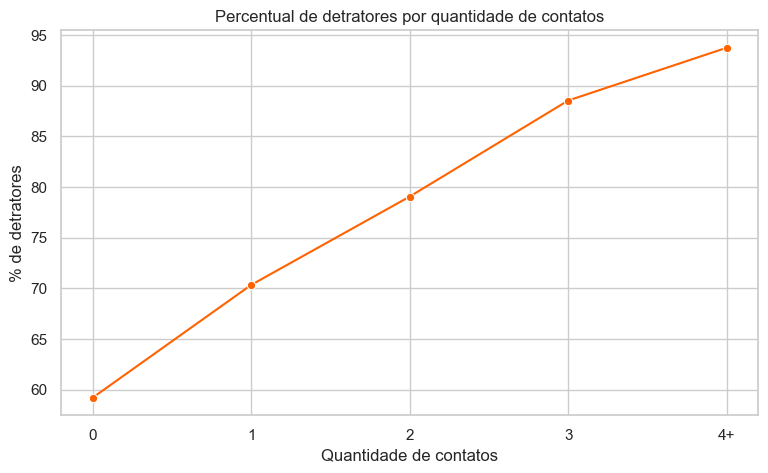

In [105]:
# CÉLULA 25 — DETRATORES POR QUANTIDADE DE CONTATOS

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=resumo_contatos,
    x="contacts_band",
    y="perc_detratores",
    marker="o",
    color='#ff6200'
)

plt.title("Percentual de detratores por quantidade de contatos")
plt.xlabel("Quantidade de contatos")
plt.ylabel("% de detratores")

plt.savefig(FIGURES_PATH / "detratores_por_contatos_atendimento.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretação

Para um gestor de operações, a principal pergunta não é apenas se essa variável afeta o NPS, mas **a partir de qual faixa a experiência começa a se deteriorar de forma relevante**.

Quando o percentual de detratores aumenta conforme a faixa operacional piora, a variável pode ser usada como gatilho para ações preventivas, priorização de atendimento ou revisão de processo.

## 8. Impacto do tempo de resolução

Tempo de resolução indica a velocidade da empresa para resolver problemas. Quanto maior a demora, maior o risco de frustração e queda na satisfação.

A análise por faixa facilita a leitura executiva, pois mostra como a satisfação muda conforme o problema operacional se intensifica.

In [73]:
# CÉLULA 26 — RESUMO POR TEMPO DE RESOLUÇÃO

resumo_resolucao = resumo_por_grupo(df_eda, "resolution_band")

resumo_resolucao

,resolution_band,qtd_clientes,nps_medio,perc_detratores,perc_promotores,taxa_recompra_30d
0,0-2,629,5.04,64.23,11.92,12.88
1,3-5,619,4.51,73.18,9.53,10.18
2,6-8,637,4.18,77.39,6.44,7.22
3,9+,615,3.78,81.46,4.23,4.55


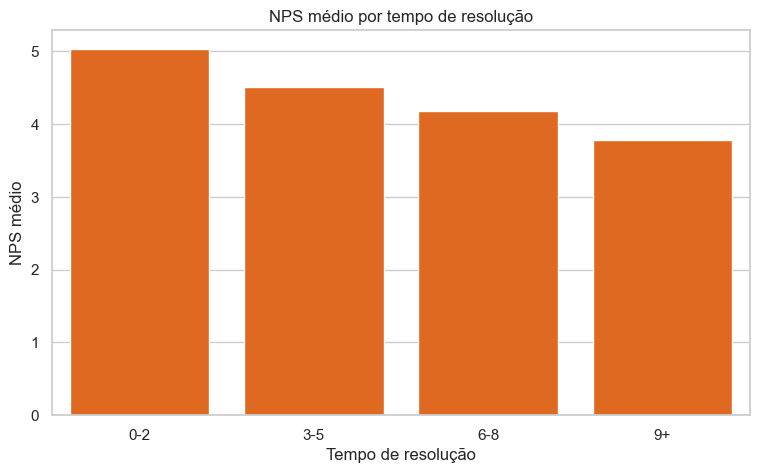

In [106]:
# CÉLULA 27 — NPS MÉDIO POR TEMPO DE RESOLUÇÃO

plt.figure(figsize=(9, 5))

sns.barplot(
    data=resumo_resolucao,
    x="resolution_band",
    y="nps_medio",
    color='#ff6200'
)

plt.title("NPS médio por tempo de resolução")
plt.xlabel("Tempo de resolução")
plt.ylabel("NPS médio")

plt.savefig(FIGURES_PATH / "nps_por_tempo_resolucao.png", dpi=300, bbox_inches="tight")
plt.show()

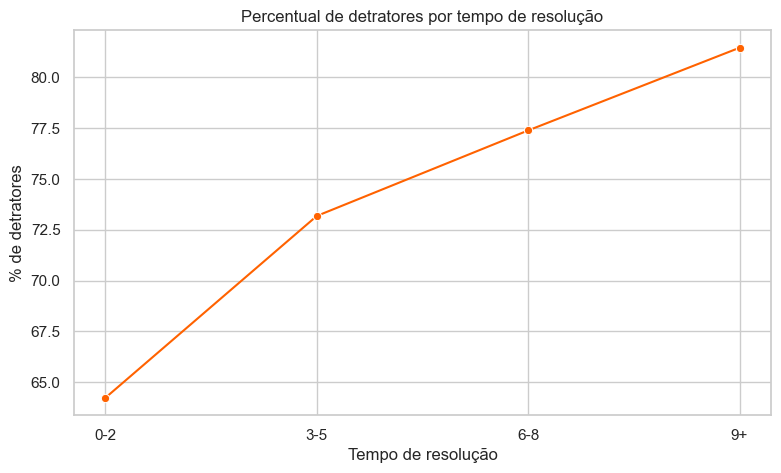

In [107]:
# CÉLULA 28 — DETRATORES POR TEMPO DE RESOLUÇÃO

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=resumo_resolucao,
    x="resolution_band",
    y="perc_detratores",
    marker="o",
    color='#ff6200'
)

plt.title("Percentual de detratores por tempo de resolução")
plt.xlabel("Tempo de resolução")
plt.ylabel("% de detratores")

plt.savefig(FIGURES_PATH / "detratores_por_tempo_resolucao.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretação

Para um gestor de operações, a principal pergunta não é apenas se essa variável afeta o NPS, mas **a partir de qual faixa a experiência começa a se deteriorar de forma relevante**.

Quando o percentual de detratores aumenta conforme a faixa operacional piora, a variável pode ser usada como gatilho para ações preventivas, priorização de atendimento ou revisão de processo.

## 9. Existe algum ponto de ruptura na experiência?

Um ponto de ruptura ocorre quando uma pequena piora operacional gera uma queda desproporcional na satisfação.

Nesta análise, buscamos identificar faixas a partir das quais o NPS cai de forma mais intensa ou o percentual de detratores cresce rapidamente.

In [76]:
# CÉLULA 29 — VARIAÇÃO DO NPS ENTRE FAIXAS OPERACIONAIS

def calcular_variacao_nps(resumo, coluna_grupo):
    # Calcula a diferença do NPS médio entre uma faixa e a faixa anterior.
    resultado = resumo.copy()
    resultado["variacao_nps_vs_faixa_anterior"] = resultado["nps_medio"].diff()
    return resultado[[coluna_grupo, "qtd_clientes", "nps_medio", "variacao_nps_vs_faixa_anterior", "perc_detratores"]]

variacao_atraso = calcular_variacao_nps(resumo_atraso, "delay_band")
variacao_reclamacoes = calcular_variacao_nps(resumo_reclamacoes, "complaints_band")
variacao_contatos = calcular_variacao_nps(resumo_contatos, "contacts_band")
variacao_resolucao = calcular_variacao_nps(resumo_resolucao, "resolution_band")

display(variacao_atraso)
display(variacao_reclamacoes)
display(variacao_contatos)
display(variacao_resolucao)

,delay_band,qtd_clientes,nps_medio,variacao_nps_vs_faixa_anterior,perc_detratores
0,0,277,6.86,NaN,36.46
1,1,615,5.55,-1.31,59.67
2,2,646,4.58,-0.97,75.39
3,3,525,3.44,-1.14,89.71
4,4-5,386,2.15,-1.29,96.89
5,6+,51,0.81,-1.34,100.00


,complaints_band,qtd_clientes,nps_medio,variacao_nps_vs_faixa_anterior,perc_detratores
0,0,23,8.52,NaN,4.35
1,1,122,7.77,-0.75,8.20
2,2,277,6.05,-1.72,43.32
3,3,507,4.91,-1.14,67.65
4,4-5,1044,3.98,-0.93,84.20
5,6+,527,2.82,-1.16,94.50


,contacts_band,qtd_clientes,nps_medio,variacao_nps_vs_faixa_anterior,perc_detratores
0,0,554,5.54,NaN,59.21
1,1,816,4.66,-0.88,70.34
2,2,640,4.12,-0.54,79.06
3,3,314,3.20,-0.92,88.54
4,4+,176,2.47,-0.73,93.75


,resolution_band,qtd_clientes,nps_medio,variacao_nps_vs_faixa_anterior,perc_detratores
0,0-2,629,5.04,NaN,64.23
1,3-5,619,4.51,-0.53,73.18
2,6-8,637,4.18,-0.33,77.39
3,9+,615,3.78,-0.40,81.46


### Interpretação

Esta etapa transforma a análise em ação.

Em vez de apenas dizer que atrasos, reclamações e contatos reduzem o NPS, a empresa pode identificar limites operacionais críticos:

- a partir de quantos dias de atraso o NPS passa a cair mais rapidamente;
- a partir de quantas reclamações o cliente praticamente se torna detrator;
- a partir de quantos contatos o atendimento deixa de recuperar a experiência.

Esses pontos podem virar regras de priorização operacional.

## 10. Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

Agora analisamos características do cliente e do pedido.

O objetivo é entender se existem perfis mais associados à satisfação ou insatisfação, considerando:

- região;
- idade;
- tempo de relacionamento;
- valor do pedido;
- quantidade de itens;
- valor de frete;
- recompra em 30 dias.

In [77]:
# CÉLULA 30 — NPS MÉDIO POR REGIÃO

resumo_regiao = resumo_por_grupo(df_eda, "customer_region")

resumo_regiao

,customer_region,qtd_clientes,nps_medio,perc_detratores,perc_promotores,taxa_recompra_30d
0,Centro-Oeste,468,4.21,74.36,7.69,8.33
1,Nordeste,485,4.42,74.02,7.01,7.63
2,Norte,506,4.38,74.51,7.51,7.91
3,Sudeste,520,4.37,74.62,8.27,8.85
4,Sul,521,4.49,72.74,9.60,10.75


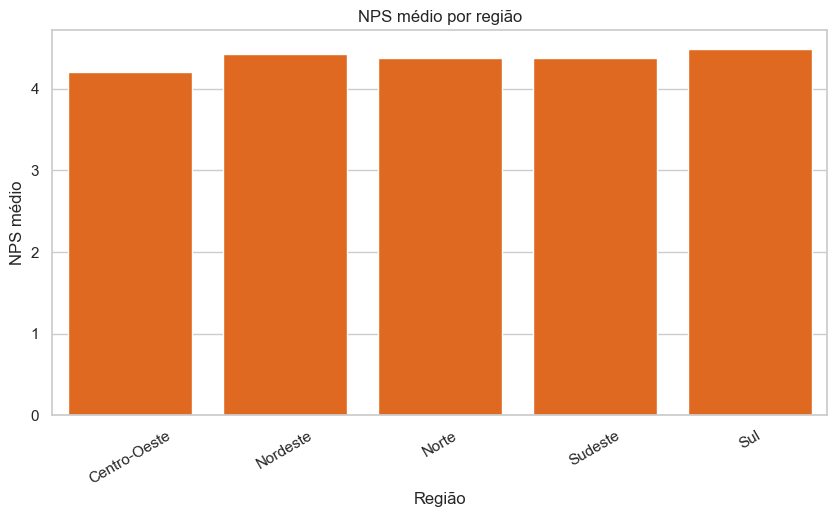

In [108]:
# CÉLULA 31 — GRÁFICO: NPS MÉDIO POR REGIÃO

plt.figure(figsize=(10, 5))

sns.barplot(
    data=resumo_regiao,
    x="customer_region",
    y="nps_medio",
    color='#ff6200'
)

plt.title("NPS médio por região")
plt.xlabel("Região")
plt.ylabel("NPS médio")
plt.xticks(rotation=30)

plt.savefig(FIGURES_PATH / "nps_por_regiao.png", dpi=300, bbox_inches="tight")
plt.show()

In [79]:
# CÉLULA 32 — NPS MÉDIO POR FAIXA ETÁRIA

resumo_idade = resumo_por_grupo(df_eda, "age_band")

resumo_idade

,age_band,qtd_clientes,nps_medio,perc_detratores,perc_promotores,taxa_recompra_30d
0,Até 25,389,4.48,75.84,8.48,9.00
1,26-35,465,4.56,70.97,8.60,9.89
2,36-45,517,4.12,77.56,6.19,6.58
3,46-55,468,4.41,72.01,8.55,9.40
4,56-65,476,4.27,75.42,7.35,7.77
5,66+,185,4.64,69.73,11.35,11.89


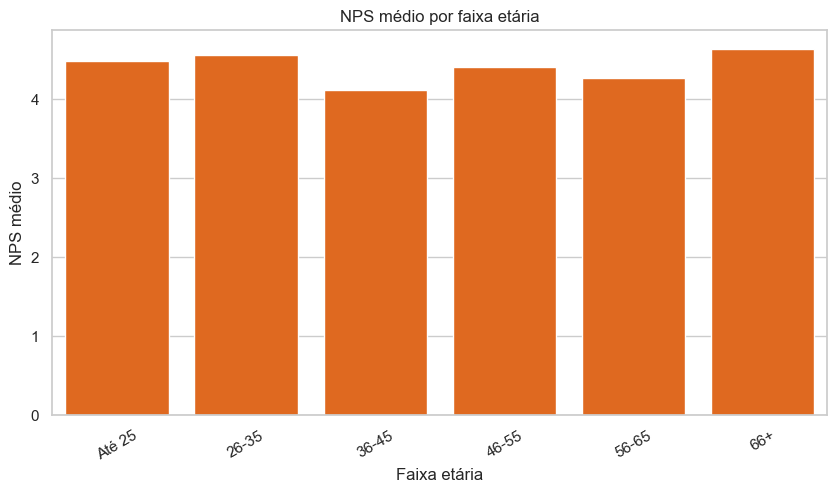

In [109]:
# CÉLULA 33 — GRÁFICO: NPS MÉDIO POR FAIXA ETÁRIA

plt.figure(figsize=(10, 5))

sns.barplot(
    data=resumo_idade,
    x="age_band",
    y="nps_medio",
    color='#ff6200'
)

plt.title("NPS médio por faixa etária")
plt.xlabel("Faixa etária")
plt.ylabel("NPS médio")
plt.xticks(rotation=30)

plt.savefig(FIGURES_PATH / "nps_por_idade.png", dpi=300, bbox_inches="tight")
plt.show()

In [81]:
# CÉLULA 34 — NPS MÉDIO POR TEMPO DE RELACIONAMENTO

resumo_tenure = resumo_por_grupo(df_eda, "tenure_band")

resumo_tenure

,tenure_band,qtd_clientes,nps_medio,perc_detratores,perc_promotores,taxa_recompra_30d
0,0-12,242,4.15,76.03,6.20,7.02
1,13-36,490,4.55,72.45,8.57,8.57
2,37-60,478,4.30,74.48,6.07,6.90
3,61-84,542,4.52,71.22,10.33,10.89
4,85+,748,4.29,76.20,7.89,8.96


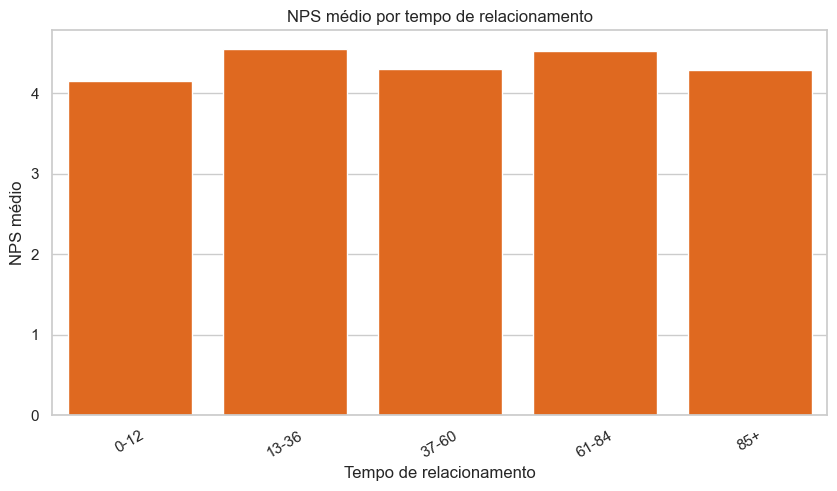

In [110]:
# CÉLULA 35 — GRÁFICO: NPS MÉDIO POR TEMPO DE RELACIONAMENTO

plt.figure(figsize=(10, 5))

sns.barplot(
    data=resumo_tenure,
    x="tenure_band",
    y="nps_medio",
    color='#ff6200'
)

plt.title("NPS médio por tempo de relacionamento")
plt.xlabel("Tempo de relacionamento")
plt.ylabel("NPS médio")
plt.xticks(rotation=30)

plt.savefig(FIGURES_PATH / "nps_por_tenure.png", dpi=300, bbox_inches="tight")
plt.show()

In [83]:
# CÉLULA 36 — NPS MÉDIO POR RECOMPRA EM 30 DIAS

resumo_recompra = resumo_por_grupo(df_eda, "repeat_purchase_30d")

resumo_recompra

,repeat_purchase_30d,qtd_clientes,nps_medio,perc_detratores,perc_promotores,taxa_recompra_30d
0,0,2282,3.94,81.11,0.00,0.00
1,1,218,9.01,0.00,92.20,100.00


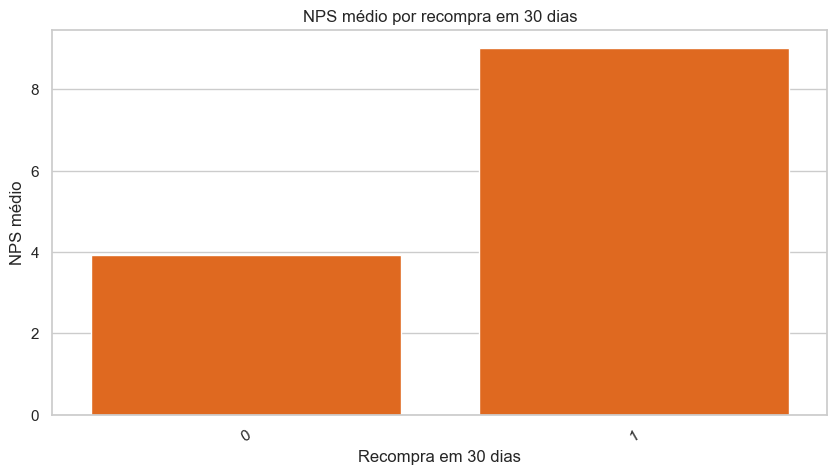

In [111]:
# CÉLULA 37 — GRÁFICO: NPS MÉDIO POR RECOMPRA EM 30 DIAS

plt.figure(figsize=(10, 5))

sns.barplot(
    data=resumo_recompra,
    x="repeat_purchase_30d",
    y="nps_medio",
    color='#ff6200'
)

plt.title("NPS médio por recompra em 30 dias")
plt.xlabel("Recompra em 30 dias")
plt.ylabel("NPS médio")
plt.xticks(rotation=30)

plt.savefig(FIGURES_PATH / "nps_por_recompra_30d_bar.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretação

A análise por perfil ajuda a identificar se a satisfação está mais relacionada a características do cliente ou à qualidade da operação.

Caso idade, região ou tempo de relacionamento apresentem diferenças pequenas, isso sugere que o problema está menos no perfil do cliente e mais na jornada operacional.

Por outro lado, se variáveis como atraso, reclamações e atendimento apresentarem diferenças fortes, a recomendação deve priorizar melhorias operacionais.

## 11. Matriz de relação entre fatores operacionais

Alguns fatores podem ocorrer ao mesmo tempo. Por exemplo:

- atraso pode gerar contato com atendimento;
- contato pode gerar reclamação;
- reclamação pode aumentar o tempo de resolução;
- tempo de resolução alto pode reduzir o NPS.

Por isso, é útil observar a relação entre as principais variáveis operacionais.

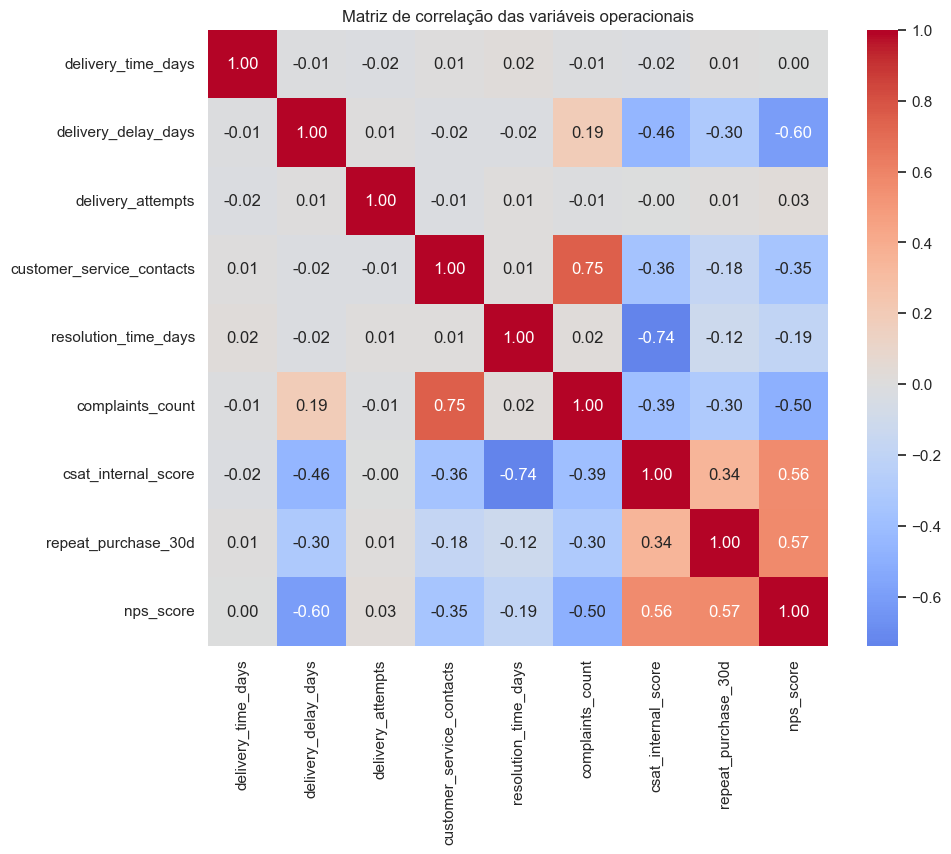

In [85]:
# CÉLULA 38 — MATRIZ DE CORRELAÇÃO DAS VARIÁVEIS OPERACIONAIS

variaveis_operacionais = [
    "delivery_time_days",
    "delivery_delay_days",
    "delivery_attempts",
    "customer_service_contacts",
    "resolution_time_days",
    "complaints_count",
    "csat_internal_score",
    "repeat_purchase_30d",
    "nps_score"
]

corr_operacional = df_eda[variaveis_operacionais].corr(numeric_only=True)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_operacional,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlação das variáveis operacionais")

plt.savefig(FIGURES_PATH / "matriz_correlacao_operacional.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretação

A matriz de correlação ajuda a entender como os problemas operacionais se relacionam.

Para o negócio, essa leitura é importante porque muitas vezes o cliente não avalia um fator isolado. A percepção de satisfação é formada pela combinação da experiência:

- entrega;
- atendimento;
- resolução;
- confiança;
- esforço necessário para resolver problemas.

## 12. O que mais gera detratores?

Nesta etapa, a análise será invertida: em vez de olhar o NPS médio por variável, vamos comparar o perfil operacional dos detratores, neutros e promotores.

Isso ajuda a responder: **o que diferencia um cliente detrator de um cliente promotor?**

In [86]:
# CÉLULA 39 — PERFIL MÉDIO POR CLASSE DE NPS

perfil_por_classe_nps = (
    df_eda
    .groupby("nps_class", observed=False)
    .agg(
        qtd_clientes=("customer_id", "count"),
        idade_media=("customer_age", "mean"),
        relacionamento_medio_meses=("customer_tenure_months", "mean"),
        valor_pedido_medio=("order_value", "mean"),
        frete_medio=("freight_value", "mean"),
        tempo_entrega_medio=("delivery_time_days", "mean"),
        atraso_medio=("delivery_delay_days", "mean"),
        tentativas_entrega_media=("delivery_attempts", "mean"),
        contatos_atendimento_medio=("customer_service_contacts", "mean"),
        tempo_resolucao_medio=("resolution_time_days", "mean"),
        reclamacoes_media=("complaints_count", "mean"),
        csat_medio=("csat_internal_score", "mean"),
        taxa_recompra_30d=("repeat_purchase_30d", "mean")
    )
    .reset_index()
)

perfil_por_classe_nps["taxa_recompra_30d"] = perfil_por_classe_nps["taxa_recompra_30d"] * 100

perfil_por_classe_nps.round(2)

,nps_class,qtd_clientes,idade_media,relacionamento_medio_meses,valor_pedido_medio,frete_medio,tempo_entrega_medio,atraso_medio,tentativas_entrega_media,contatos_atendimento_medio,tempo_resolucao_medio,reclamacoes_media,csat_medio,taxa_recompra_30d
0,Detrator,1851,43.31,61.58,428.99,38.40,8.00,2.53,1.99,1.69,5.79,4.62,2.34,0.00
1,Neutro,448,43.45,59.51,447.33,37.91,8.12,1.40,2.04,1.13,4.83,2.99,4.23,3.79
2,Promotor,201,44.08,63.04,453.69,37.21,8.04,0.76,2.03,0.78,4.10,2.39,5.60,100.00


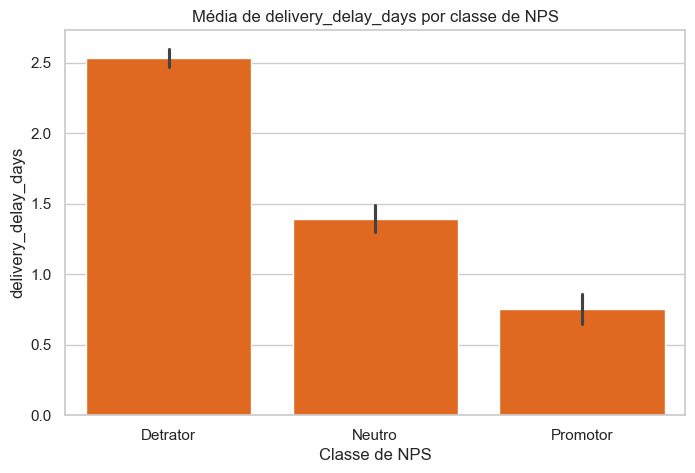

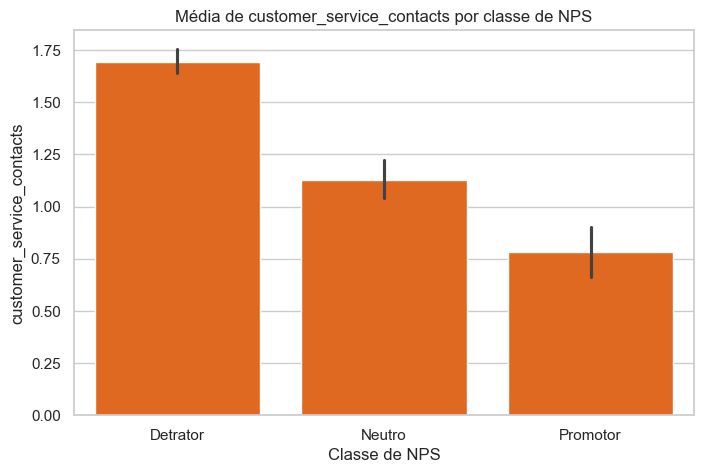

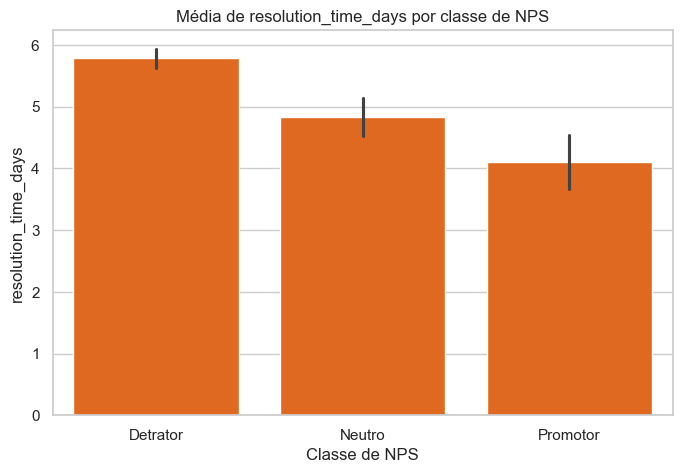

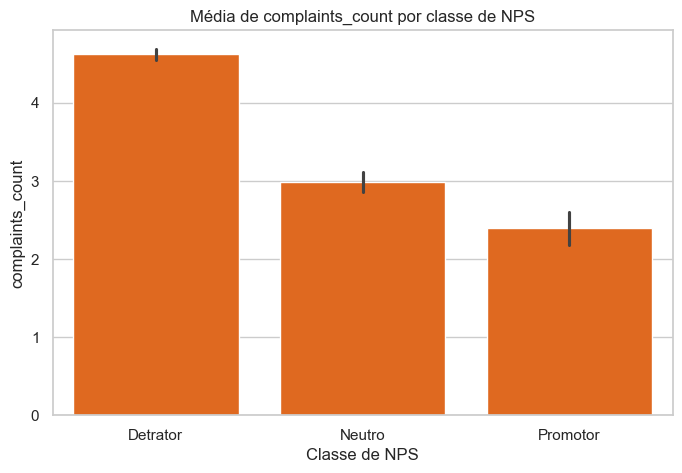

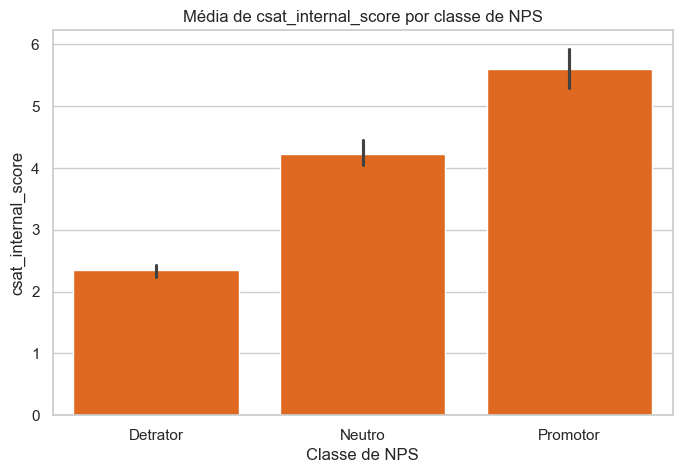

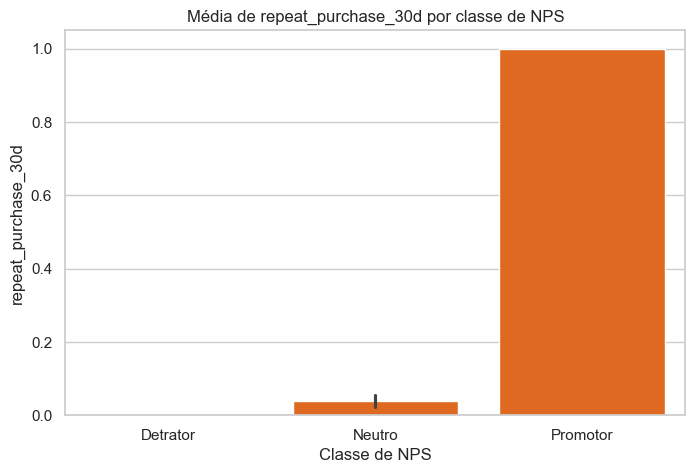

In [112]:
# CÉLULA 40 — COMPARAÇÃO VISUAL ENTRE DETRATORES, NEUTROS E PROMOTORES

metricas_comparacao = [
    "delivery_delay_days",
    "customer_service_contacts",
    "resolution_time_days",
    "complaints_count",
    "csat_internal_score",
    "repeat_purchase_30d"
]

for metrica in metricas_comparacao:
    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=df_eda,
        x="nps_class",
        y=metrica,
        order=ordem_nps,
        color='#ff6200'
    )

    plt.title(f"Média de {metrica} por classe de NPS")
    plt.xlabel("Classe de NPS")
    plt.ylabel(metrica)

    nome_arquivo = f"media_{metrica}_por_classe_nps.png"
    plt.savefig(FIGURES_PATH / nome_arquivo, dpi=300, bbox_inches="tight")

    plt.show()

### Interpretação

A comparação entre classes permite identificar os fatores mais característicos dos detratores.

Em geral, os detratores tendem a concentrar:

- maior atraso;
- mais reclamações;
- mais contatos com atendimento;
- maior tempo de resolução;
- menor score interno de satisfação;
- menor recompra.

Essa leitura é especialmente útil para a apresentação executiva, porque transforma a análise em uma narrativa clara:

> Clientes detratores não aparecem por acaso. Eles são resultado de uma jornada com mais fricção operacional.

## 13. Síntese dos principais insights

Esta seção consolida os achados da análise exploratória em linguagem executiva.

A ideia é apoiar a construção dos slides e facilitar a comunicação com um público não técnico.

In [88]:
# CÉLULA 41 — TABELA EXECUTIVA DE INSIGHTS

insights_executivos = pd.DataFrame({
    "pergunta_de_negocio": [
        "Quais fatores parecem mais críticos para a satisfação?",
        "O que mais gera detratores?",
        "Existe ponto de ruptura na experiência?",
        "Que tipo de cliente tende a ter NPS mais alto?",
        "Que tipo de cliente tende a ter NPS mais baixo?"
    ],
    "resposta_executiva": [
        "Os principais fatores associados ao NPS são atraso na entrega, reclamações, contatos com atendimento, tempo de resolução, CSAT interno e recompra em 30 dias.",
        "Detratores estão mais associados a jornadas com atraso, múltiplas reclamações, maior esforço no atendimento e menor percepção interna de satisfação.",
        "Os pontos de ruptura devem ser observados principalmente nas faixas de atraso, reclamações e contatos com atendimento, pois o NPS tende a cair conforme esses eventos aumentam.",
        "Clientes com menos fricção operacional, menor atraso, menos reclamações, maior CSAT interno e recompra em 30 dias tendem a apresentar NPS mais alto.",
        "Clientes expostos a atraso, reclamações recorrentes, múltiplos contatos e maior tempo de resolução tendem a apresentar NPS mais baixo."
    ],
    "area_impactada": [
        "Logística, Atendimento e CX",
        "Atendimento, Operações e CX",
        "Logística, Atendimento e Operações",
        "CRM, Produto e CX",
        "Retenção, Atendimento e Logística"
    ]
})

insights_executivos

,pergunta_de_negocio,resposta_executiva,area_impactada
0,Quais fatores parecem mais críticos para a sat...,Os principais fatores associados ao NPS são at...,"Logística, Atendimento e CX"
1,O que mais gera detratores?,Detratores estão mais associados a jornadas co...,"Atendimento, Operações e CX"
2,Existe ponto de ruptura na experiência?,Os pontos de ruptura devem ser observados prin...,"Logística, Atendimento e Operações"
3,Que tipo de cliente tende a ter NPS mais alto?,"Clientes com menos fricção operacional, menor ...","CRM, Produto e CX"
4,Que tipo de cliente tende a ter NPS mais baixo?,"Clientes expostos a atraso, reclamações recorr...","Retenção, Atendimento e Logística"


## 14. Recomendações práticas para o negócio

Com base na análise exploratória, algumas ações podem ser priorizadas:

### 1. Monitorar atraso como gatilho de risco

Clientes com atraso devem ser sinalizados antes da pesquisa de NPS. A empresa pode criar alertas para casos com risco elevado de insatisfação.

### 2. Reduzir esforço no atendimento

Múltiplos contatos indicam fricção. O negócio deve acompanhar indicadores como recontato, tempo de resolução e reclamações por pedido.

### 3. Atuar preventivamente em clientes com alto risco de detrator

Combinações como atraso + reclamação + atendimento demorado podem acionar ações preventivas, como contato proativo ou compensação.

### 4. Integrar logística, atendimento e experiência do cliente

O NPS não deve ser tratado apenas como métrica de satisfação, mas como reflexo da jornada operacional completa.

### 5. Usar os achados como base para o modelo preditivo

As variáveis mais associadas ao NPS nesta EDA podem ser candidatas importantes para o notebook opcional de modelagem preditiva.

## 15. Limitações da análise

Apesar dos achados serem úteis para orientar decisões, esta análise possui limitações:

1. **Correlação não implica causalidade**  
   Uma variável associada ao NPS não necessariamente causa a mudança na satisfação.

2. **A base representa um recorte histórico**  
   Os padrões encontrados podem mudar conforme sazonalidade, promoções, região ou mudanças operacionais.

3. **Variáveis disponíveis limitam a explicação**  
   Outros fatores relevantes podem não estar presentes na base, como tipo de produto, transportadora, canal de venda ou histórico completo do cliente.

4. **NPS é coletado após a experiência**  
   A nota representa a percepção final do cliente, mas pode ser influenciada por eventos recentes ou subjetivos.

5. **A análise não substitui experimentação**  
   Para confirmar impacto causal, seriam necessários testes controlados, análises temporais ou experimentos de negócio.

In [89]:
# CÉLULA 42 — EXPORTAÇÃO DA BASE TRATADA

df_eda.to_csv(PROCESSED_DATA_PATH, index=False)

print("Base tratada exportada com sucesso em:")
print(PROCESSED_DATA_PATH)

Base tratada exportada com sucesso em:
..\data\processed\base_nps_tratada.csv


In [90]:
# CÉLULA 43 — EXPORTAÇÃO DAS TABELAS DE APOIO PARA REPORTS

resumo_atraso.to_csv(FIGURES_PATH / "tabela_resumo_atraso.csv", index=False)
resumo_reclamacoes.to_csv(FIGURES_PATH / "tabela_resumo_reclamacoes.csv", index=False)
resumo_contatos.to_csv(FIGURES_PATH / "tabela_resumo_contatos.csv", index=False)
resumo_resolucao.to_csv(FIGURES_PATH / "tabela_resumo_resolucao.csv", index=False)
insights_executivos.to_csv(FIGURES_PATH / "tabela_insights_executivos.csv", index=False)

print("Tabelas de apoio exportadas com sucesso.")

Tabelas de apoio exportadas com sucesso.


# Conclusão do notebook

A EDA indica que a satisfação do cliente está fortemente relacionada à qualidade da jornada operacional.

Os principais fatores associados à queda do NPS são:

- atraso na entrega;
- aumento de reclamações;
- maior quantidade de contatos com atendimento;
- maior tempo de resolução;
- menor score interno de satisfação;
- ausência de recompra em 30 dias.

A principal leitura de negócio é que o NPS não deve ser analisado apenas como uma nota final. Ele deve ser interpretado como reflexo da experiência completa do cliente, especialmente nos pontos de logística e atendimento.

Esses achados servem como base para:

1. construção dos slides executivos;
2. definição de recomendações práticas para o negócio;
3. seleção de variáveis candidatas para o modelo preditivo opcional.